In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 949.8/949.8 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 102.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 67.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 82.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstal

In [ ]:
!pip install deep_sort_realtime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 40.1 MB/s eta 0:00:00


INSTALLING DEEPSORT FOR DEEP SORT DETECTION


In [ ]:
from deep_sort_realtime.deepsort_tracker import DeepSort

class Tracker:
  def __init__(self):
    self.object_tracker = DeepSort(
        max_age=20,
        n_init=2,
        nms_max_overlap=0.3,
        max_cosine_distance=0.8,
        nn_budget=None,
        override_track_class=None,
        embedder="mobilenet",
        half=True,
        bgr=True,
        embedder_model_name=None,
        embedder_wts=None,
        polygon=False,
        today=None
    )

  def track(self, detections, frame, obj_ids, centre_obj_coordinates):
    tracks = self.object_tracker.update_tracks(detections, frame=frame)
    obj_classes = []
    tracking_ids = []
    obj_coords = []
    boxes = []
    for track, labels, coords in zip(tracks, obj_ids, centre_obj_coordinates):
      if not track.is_confirmed():
        continue
      tracking_ids.append(track.track_id)
      obj_classes.append(labels)
      ltrb = track.to_ltrb()
      boxes.append(ltrb)
      obj_coords.append(coords)
    return tracking_ids, boxes, obj_classes, obj_coords

In [ ]:
from ultralytics import YOLO


class YoloDetector:
  def __init__(self, model_path, confidence):
    self.model = YOLO(model_path)
    self.classList = ["person", "car", "truck", "motorcycle",  "bus"]
    self.confidence = confidence

  def detect(self, image):
    results = self.model.predict(image, conf=self.confidence)
    result = results[0]
    detections = self.make_detections(result)
    return detections

  def make_detections(self, result):
    boxes = result.boxes
    detections = []
    for box in boxes:
      x1, y1, x2, y2 = box.xyxy[0]
      x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)
      w, h = x2 - x1, y2 - y1
      class_number = int(box.cls[0])

      if result.names[class_number] not in self.classList:
        continue
      conf = box.conf[0]
      detections.append((([x1, y1, w, h]), class_number, conf, result.names[class_number]))
    return detections

In [ ]:
import cv2
import time
from google.colab.patches import cv2_imshow
import numpy as np
# drawing the lines for the video for classification
def draw_lines(frame):
  line1 = (200,600)
  line2 = (1300, 900)
  line5 = (100, 700) # pedestrian box (900,900), (1350, 900), (800, 600), (300, 650)
  line6 = (350, 900) # lanes in usa one
  color = (0, 1, 0) # (250, 200), (575, 200), (575, 570), (250, 570) panama one
  #pts = np.array([[900, 900], [1400, 900], [800, 600], [200, 600]],np.int32) for the short video video
  pts = np.array([[300, 570], [750, 570], [650, 150], [500, 150]],np.int32) #  left lane
  #pts2 = np.array([[610, 550], [750, 550], [650, 150], [596, 150]],np.int32) # mid right
  pts3 = np.array([[770, 550], [900, 550], [770, 200], [670, 200]],np.int32) # right lane
  #pts4 = np.array([[300, 550], [450, 550], [450, 200], [300, 200]],np.int32) # left lane
  #pts = pts.reshape((-1, 1, 2))
  #frame = cv2.rectangle(frame, line1, line2, color, thickness = 5)
  #frame = cv2.rectangle(frame, line5, line6, color, thickness = 5)
  #frame =cv2.polylines(frame, [pts4], True, color, thickness = 2)
  frame =cv2.polylines(frame, [pts3], True, color, thickness = 2)
  #frame =cv2.polylines(frame, [pts2], True, color, thickness = 2)
  frame =cv2.polylines(frame, [pts], True, color, thickness = 2)
  return frame


Publisher and Subscriber model code

In [ ]:

import queue

class Publisher:
    def __init__(self):
        self.message_queue = queue.Queue()
        self.subscribers = []

    def subscribe(self, subscriber):
        self.subscribers.append(subscriber)

    def publish(self, message):
        self.message_queue.put(message)
        for subscriber in self.subscribers:
            subscriber.receive(message)

class Subscriber:
    def __init__(self, name):
        self.name = name

    def receive(self, message):
        print(f"{self.name}"+"received message:"
              +f"{message}")


In [ ]:
from shapely.geometry import Point
from shapely.geometry.polygon import Polygon

In [ ]:
class Detection_model:
  def __init__(self):
    self.MODEL_PATH =  "yolo11n.pt"
    self.VIDEO_PATH = "../trafficData/four lanes.mp4" # "../trafficData/multiLane_traffic.mp4" Daytime off Peak 1min V2
    self.detector = YoloDetector(model_path=self.MODEL_PATH, confidence=0.2)
    self.tracker = Tracker()
    # publisher
    self.publisher = Publisher()

    # total objects in each box
    self.lane_one_current_total = 0
    self.lane_two_current_total = 0
    self.lane_three_current_total = 0
    self.lane_four_current_total = 0

    # used for adding up the total amount in each lane
    self.lane_one_total = 0
    self.lane_two_total = 0
    self.lane_three_total = 0
    self.lane_four_total = 0

    # wait time variables, time recorded only works for a set fps
    self.wait_time_tracker = {}
    self.lane_one_waittime = []
    self.lane_two_waittime = []
    self.lane_three_waittime = []
    self.lane_four_waittime = []
    # time tracker
    self.time_tracker = 0
    self.lane_count_record = [[], [], [], []] # historical tracker of lane queue length
    self.wait_time_record = [[], [], [], []] # historical tracker of wait time
    # identifying objects dictionaries can be combined for more compactness
    # 0 = person, 2 = car, 3 = motorcycle, 5 = bus, 7=truck
    self.total_no_of_objects = {1:{0:0, 2:0, 3:0, 5 :0, 7:0}, 2:{0:0, 2:0, 3:0, 5 :0, 7:0},
                                3:{0:0, 2:0, 3:0, 5 :0, 7:0}, 4:{0:0, 2:0, 3:0, 5 :0, 7:0}}
    self.label ={0:"person", 2:"car", 3:"motorcycle", 5:"bus", 7:"truck"}
    # lane coordinates
    self.video_fps = 30

  # updates wait time list
  def update_wait_time(self, tracking_id):
    if tracking_id not in self.wait_time_tracker:
      self.wait_time_tracker[tracking_id] = 1
    else:
      self.wait_time_tracker[tracking_id] += 1
  def main(self):

    cap = cv2.VideoCapture(self.VIDEO_PATH)
    # Get video properties: width, height, and frames per second (fps)
    w, h, fps = (int(cap.get(x)) for x in (cv2.CAP_PROP_FRAME_WIDTH, cv2.CAP_PROP_FRAME_HEIGHT, cv2.CAP_PROP_FPS))

    # Video writer
    video_writer = cv2.VideoWriter("trackzone.avi",
                                cv2.VideoWriter_fourcc(*"mp4v"),
                                fps, (w, h))

    if not cap.isOpened():
      print("Error: Unable to open video file.")
      exit()

    while True:
      ret, frame = cap.read()
      if not ret:
        break

      #start_time = time.perf_counter()

      # draw the car lane lines
      frame = draw_lines(frame)
      detections = self.detector.detect(frame)

      detected_object_classes = [x[1] for x in detections]

      centre_obj_coordinates = [(x[0][0],x[0][1]) for x in detections]

      tracking_ids, boxes, class_ids, centre_coordinates = self.tracker.track(detections, frame, detected_object_classes, centre_obj_coordinates)


      for tracking_id, bounding_box, detected_class, coords in zip(tracking_ids, boxes, class_ids, centre_coordinates):
        cv2.rectangle(frame, (int(bounding_box[0]), int(bounding_box[1])), (int(
            bounding_box[2]), int(bounding_box[3])), (0, 0, 255), 2)
        cv2.putText(frame, str(self.label[detected_class]) + ":" + str(tracking_id), (int(bounding_box[0]), int(
            bounding_box[1] - 10)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

        point = Point(coords[0], coords[1])
        lower_right_point = Point((int(bounding_box[2]), int(bounding_box[3])))
        # lane 1 counting
        if (Polygon([(300, 570), (750, 570), (650, 150),(500, 150)]).contains(point)) :
          self.lane_one_current_total += 1
          self.update_wait_time(tracking_id)



          # objects must meet a certain threshold in existing on screen
          if self.wait_time_tracker[tracking_id] == 30:
            self.lane_one_total+=1
            self.total_no_of_objects[1][detected_class] += 1

          self.lane_one_waittime.append((self.wait_time_tracker[tracking_id] / self.video_fps))

        #lane 2 counting
        elif Polygon([(610, 550), (750, 550), (650, 150), (596, 150)]).contains(point):
          self.lane_two_current_total += 1
          self.update_wait_time(tracking_id)

          # objects must meet a certain threshold in existing on screen
          if self.wait_time_tracker[tracking_id] == 30:
            self.lane_two_total +=1
            self.total_no_of_objects[2][detected_class] += 1

          self.lane_two_waittime.append((self.wait_time_tracker[tracking_id] / self.video_fps))
        # lane 3 770, 550], [900, 550], [770, 200], [670, 200
        elif (Polygon([(770, 550), (900, 550), (770, 200), (670, 200)]).contains(point)) or (Polygon([(780, 420), (855, 580), (1180, 570), (1050, 400)]).contains(lower_right_point)):
          self.lane_three_current_total += 1
          self.update_wait_time(tracking_id)

          # objects must meet a certain threshold in existing on screen
          if self.wait_time_tracker[tracking_id] == 30:
            self.lane_three_total +=1
            self.total_no_of_objects[3][detected_class] += 1

          self.lane_three_waittime.append((self.wait_time_tracker[tracking_id] / self.video_fps))
        #lane 4
        # elif Polygon([(370, 480), (350, 400), (140, 440), (140, 520)]).contains(point):
        #   self.lane_four_current_total += 1
        #   self.update_wait_time(tracking_id)

        #   # objects must meet a certain threshold in existing on screen
        #   if self.wait_time_tracker[tracking_id] == 30:
        #     self.lane_four_total +=1
        #     self.total_no_of_objects[4][detected_class] += 1

        #   self.lane_four_waittime.append((self.wait_time_tracker[tracking_id] / self.video_fps))


      self.time_tracker +=1
      if (self.time_tracker % 30) == 0:
        self.lane_count_record[0].append(self.lane_one_current_total)
        self.lane_count_record[1].append(self.lane_two_current_total)
        self.lane_count_record[2].append(self.lane_three_current_total)
        self.lane_count_record[3].append(self.lane_four_current_total)

        if self.lane_one_current_total != 0:
          self.wait_time_record[0].append(sum(self.lane_one_waittime) / self.lane_one_current_total)
        else:
          self.wait_time_record[0].append(0)
        if self.lane_two_current_total != 0:
          self.wait_time_record[1].append(sum(self.lane_two_waittime) / self.lane_two_current_total)
        else:
          self.wait_time_record[1].append(0)
        if self.lane_three_current_total != 0:
          self.wait_time_record[2].append(sum(self.lane_three_waittime) / self.lane_three_current_total)
        else:
          self.wait_time_record[2].append(0)
        # if self.lane_four_current_total != 0:
        #   self.wait_time_record[3].append(sum(self.lane_four_waittime) / self.lane_four_current_total)
        # else:
        #   self.wait_time_record[3].append(0)


      self.publisher.publish("Publisher Tester current queue length lane 1 is " + str(self.lane_two_current_total))

      print("LANE 1 CURRENT QUEUE LENGTH:" + str(self.lane_one_current_total))
      print("LANE 2 CURRENT QUEUE LENGTH:" + str(self.lane_two_current_total))
      print("LANE 3 CURRENT QUEUE LENGTH:" + str(self.lane_three_current_total))
      #print("LANE 4 CURRENT QUEUE LENGTH:" + str(self.lane_four_current_total))

      print("LANE 1 TOTAL THROUGHPUT:" + str(self.lane_one_total / (self.time_tracker / 30)))
      print("LANE 2 TOTAL THROUGHPUT:" + str(self.lane_two_total / (self.time_tracker / 30)))
      print("LANE 3 TOTAL THROUGHPUT:" + str(self.lane_three_total / (self.time_tracker / 30)))
     # print("LANE 4 TOTAL THROUGHPUT:" + str(self.lane_four_total / (self.time_tracker / 30)))


      # total object tracker
      print("TOTAL OBJECT TRACKER:")
      print("people:" + str(self.total_no_of_objects[1][0] ))
      print("cars:" + str(self.total_no_of_objects[1][2]))
      print("motorcycles:" + str(self.total_no_of_objects[1][3] ))
      print("bus:" + str(self.total_no_of_objects[1][5] ))
      print("truck:" + str(self.total_no_of_objects[1][7] ))

      print("TOTAL OBJECT LANE 2 TRACKER:")
      print("people:" + str(self.total_no_of_objects[2][0]))
      print("cars:" + str( self.total_no_of_objects[2][2]))
      print("motorcycles:" + str(self.total_no_of_objects[2][3]))
      print("bus:" + str( self.total_no_of_objects[2][5]))
      print("truck:" + str( self.total_no_of_objects[2][7]))

      print("TOTAL OBJECT LANE 3 TRACKER:")
      print("people:" + str( self.total_no_of_objects[3][0]))
      print("cars:" + str(self.total_no_of_objects[3][2]))
      print("motorcycles:" + str( self.total_no_of_objects[3][3]))
      print("bus:" + str(self.total_no_of_objects[3][5]))
      print("truck:" + str( self.total_no_of_objects[3][7]))


      # print("TOTAL OBJECT LANE 4 TRACKER:")
      # print("people:" + str( self.total_no_of_objects[4][0]))
      # print("cars:" + str(self.total_no_of_objects[4][2]))
      # print("motorcycles:" + str( self.total_no_of_objects[4][3]))
      # print("bus:" + str(self.total_no_of_objects[4][5]))
      # print("truck:" + str( self.total_no_of_objects[4][7]))

      if  self.lane_one_current_total > 0:
        print("LANES TOTAL WAIT TIME 1:" + str( sum(self.lane_one_waittime) / self.lane_one_current_total))
        cv2.putText(frame, "lane 1 wait time avg :" + str(sum(self.lane_one_waittime) / self.lane_one_current_total), (30, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 255), 2)
        cv2.putText(frame, "lane 1 queue length:" + str(self.lane_one_current_total), (30, 150), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 255), 2)

      if self.lane_two_current_total > 0:
        print("LANES TOTAL WAIT TIME 2:" + str( sum(self.lane_two_waittime) / self.lane_two_current_total))
        cv2.putText(frame, "lane 2 wait time avg :" + str(sum(self.lane_two_waittime) / self.lane_two_current_total), (30, 90), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 255), 2)
        cv2.putText(frame, "lane 2 queue length:" + str(self.lane_two_current_total), (30, 210), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 255), 2)

      if self.lane_three_current_total > 0:
        print("LANES TOTAL WAIT TIME 3:" + str( sum(self.lane_three_waittime) / self.lane_three_current_total))
        cv2.putText(frame, "lane 3 wait time avg :" + str(sum(self.lane_three_waittime) / self.lane_three_current_total), (30, 120), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 255), 2)
        cv2.putText(frame, "lane 3 queue length:" + str(self.lane_three_current_total), (30, 250), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 255), 2)

      # if self.lane_four_current_total > 0:
      #   print("LANES TOTAL WAIT TIME 4:" + str( sum(self.lane_four_waittime) / self.lane_four_current_total))
      #   cv2.putText(frame, "lane 4 wait time avg :" + str(sum(self.lane_four_waittime) / self.lane_four_current_total), (30, 90), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 255), 2)
      #   cv2.putText(frame, "lane 4 queue length:" + str(self.lane_four_current_total), (30, 210), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 255), 2)
      # updating the variables
      lane_one_last_total = self.lane_one_current_total
      lane_two_last_total = self.lane_two_current_total
      self.lane_one_current_total = 0
      self.lane_two_current_total = 0
      self.lane_three_current_total = 0
      self.lane_four_current_total = 0

      self.lane_one_waittime = []
      self.lane_two_waittime = []
      self.lane_three_waittime = []
      self.lane_four_waittime = []

      #end_time = time.perf_counter()
     # fps = 1 / (end_time - start_time)
      print(f"Current fps: {fps}")

      #cv2_imshow(frame)

      video_writer.write(frame)

    #key = cv2.waitKey(1) & 0xFF
     # if key == ord("q") or key == 27:
     #   break

    cap.release()
    video_writer.release()
    #cv2.destroyAllWindows()

    return (self.total_no_of_objects, self.lane_two_total, self.lane_one_total, self.lane_count_record, self.wait_time_record)


model = Detection_model()
subscriber_1 = Subscriber("Subscriber 1")
model.publisher.subscribe(subscriber_1)
data = model.main()

Streaming output truncated to the last 5000 lines.
TOTAL OBJECT TRACKER:
people:0
cars:29
motorcycles:0
bus:0
truck:0
TOTAL OBJECT LANE 2 TRACKER:
people:0
cars:0
motorcycles:0
bus:0
truck:0
TOTAL OBJECT LANE 3 TRACKER:
people:0
cars:1
motorcycles:0
bus:0
truck:0
LANES TOTAL WAIT TIME 1:13.511111111111111
Current fps: 29

0: 320x640 2 persons, 9 cars, 1 bus, 1 truck, 160.1ms
Speed: 2.9ms preprocess, 160.1ms inference, 1.2ms postprocess per image at shape (1, 3, 320, 640)
Subscriber 1received message:Publisher Tester current queue length lane 1 is 0
LANE 1 CURRENT QUEUE LENGTH:6
LANE 2 CURRENT QUEUE LENGTH:0
LANE 3 CURRENT QUEUE LENGTH:0
LANE 1 TOTAL THROUGHPUT:0.675990675990676
LANE 2 TOTAL THROUGHPUT:0.0
LANE 3 TOTAL THROUGHPUT:0.023310023310023312
TOTAL OBJECT TRACKER:
people:0
cars:29
motorcycles:0
bus:0
truck:0
TOTAL OBJECT LANE 2 TRACKER:
people:0
cars:0
motorcycles:0
bus:0
truck:0
TOTAL OBJECT LANE 3 TRACKER:
people:0
cars:1
motorcycles:0
bus:0
truck:0
LANES TOTAL WAIT TIME 1:13.

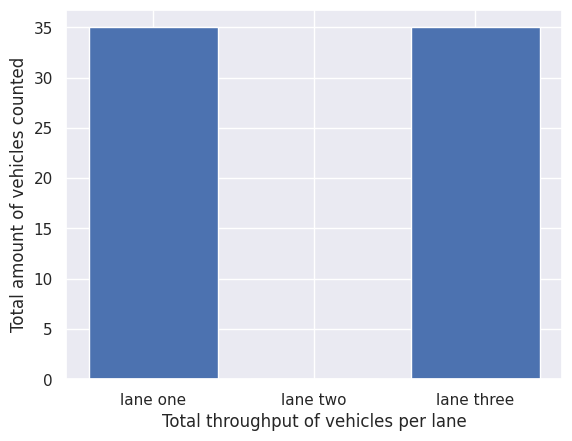

In [ ]:
import seaborn as sb
import matplotlib.pyplot as plt
import numpy as np
x = np.array(["lane one", "lane two", "lane three"])
y = np.array([int(data[2]), int(data[1]),  int(data[2])])
plt.bar(x,y)
plt.xlabel("Total throughput of vehicles per lane")
plt.ylabel("Total amount of vehicles counted")
sb.set() # for visual effects
plt.show()

In [ ]:
data[0][1]

{0: 0, 2: 39, 3: 0, 5: 0, 7: 0}

In [ ]:
data[0][2]

{0: 0, 2: 15, 3: 0, 5: 0, 7: 0}

In [ ]:
x = np.array(["pedestrians", "car", "motorcycle", "bus", "truck"])
y = np.array([int(data[0][0]), int(data[0][2]), int(data[0][3]), int(data[0][5]), int(data[0][7])])
plt.bar(x,y)
plt.xlabel("Total throughput of each type of vehicle in total")
plt.ylabel("Total amount of each vehicle")
sb.set() # for visual effects
plt.show()

KeyError: 0

ValueError: 'labels' must be of length 'x', not 5

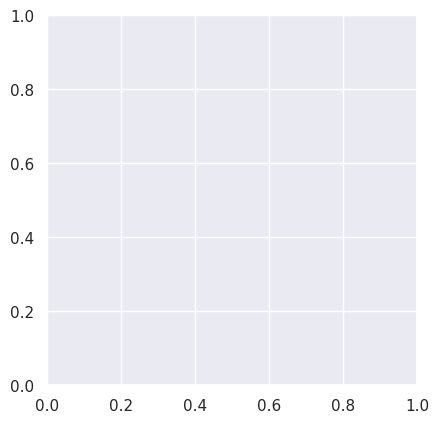

In [ ]:
pie_labels = ["pedestrians", "car", "motorcycle", "bus", "truck"]
plt.pie(y, labels = pie_labels, startangle = 90)
plt.show()

In [ ]:
len(data[3][3])

0

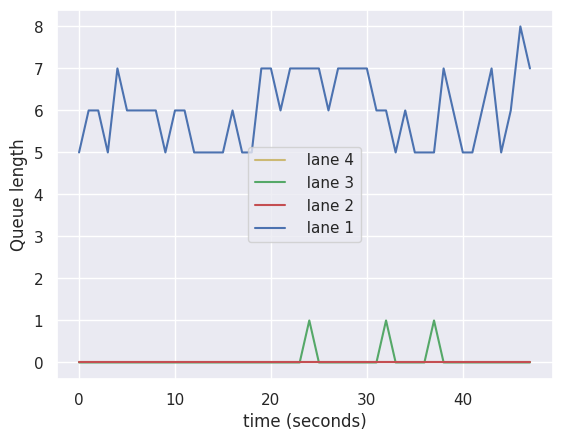

In [ ]:
time = []
time.extend(range(1,69))
y1 =  np.array(data[3][0])
y2 =  np.array(data[3][1])
y2 =  np.array(data[3][2])
y2 =  np.array(data[3][3])
plt.xlabel("time (seconds)")
plt.ylabel("Queue length")

plt.plot(np.array(data[3][3]),'y-',label='  lane 4')
plt.plot(np.array(data[3][2]),'g-',label='  lane 3')
plt.plot(np.array(data[3][1]),'r-',label='  lane 2')
plt.plot(np.array(data[3][0]),'b-',label='  lane 1')
plt.legend()
plt.show()

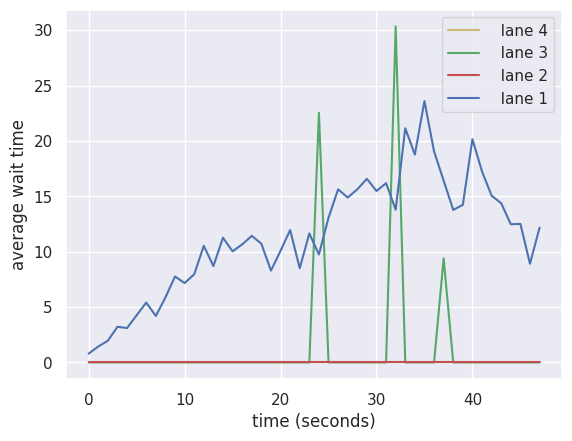

In [ ]:
time = []
time.extend(range(1,69))
y1 =  np.array(data[4][0])
y2 =  np.array(data[4][1])
y2 =  np.array(data[4][2])
y2 =  np.array(data[4][3])
plt.xlabel("time (seconds)")
plt.ylabel("average wait time")

plt.plot(np.array(data[4][3]),'y-',label='  lane 4')
plt.plot(np.array(data[4][2]),'g-',label='  lane 3')
plt.plot(np.array(data[4][1]),'r-',label='  lane 2')
plt.plot(np.array(data[4][0]),'b-',label='  lane 1')
plt.legend()
plt.show()

In [ ]:
Model = pre trained model
Tracker = Deep Sort
lane coordinates = edge coordinates of each lane
Video = Load test video
timer = tracks the current fps of the video
video fps = integer

while not finished looping frames in Video:
  draw lane coordinates onto the Video frame
  Detections, detected classes = Model(frame)
  Tracking_IDs, bounding_Boxes = Deep Sort (Detections)

  Loop Tracking_IDs, bounding_Boxes:
    if Detections coordinates or bounding_Boxes are in the relevant lane coordinates:
      Update current lane count by 1
      if trackingID not in the dictionary:
        then add the id to the dictionary with value = 1 # tracks how many frames the object has been in
      else:
        Update the trackingID value in the dictionary by + 1

      append the list containing the wait times of each lane ( trackingID dictionary fps value / timer )

      if dictionary trackingID value == video fps:
        total lane count + 1

    Publish total lane count, current lane count, sum(wait times of each lane) / current lane count,
      throughput = total lane count / (timer / video fps)

    if timer MOD video fps == 0: # records all  metrics by each second
      record all metric values

    total lane counts = combine all lanes total values

  return all metric values

